## 5. Create a Leakage-Safe Train/Test Split

The dataset contains three different modalities, but all modalities describe the same 350 physical turmeric samples.

Therefore, the train/test split must be created using the common `Sample ID` rather than independently splitting each modality.

A single stratified split is created from the master sample table and will later be applied to:

- Color measurements
- FTIR spectroscopy
- EfficientNet-B0 image features

Stratification is used to preserve the same proportion of each adulteration level in both the training and test sets.

The test set will be kept completely separate from preprocessing and model fitting.

In [647]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import os

## 2. Load the Multimodal Dataset

The FoodSure AI dataset contains three aligned modalities:

1. Color measurements
2. FTIR spectroscopy
3. EfficientNet-B0 image features

All modalities describe the same 350 physical turmeric samples and are linked using Sample ID.

The datasets are loaded independently so that this notebook can be executed without relying on variables from the EDA notebook.

In [648]:
ftir_path = "../Dataset/FTIR Spectroscopy/FTIR_Data.csv"
color_path = "../Dataset/Color Measurement/Hunter_Lab_colorimeter.csv"

efficientnet_path = (
    "../Dataset/Image/"
    "EfficientNetB0_Image_Features/"
    "EfficientNetB0_Image_Features.csv"
)

ftir = pd.read_csv(ftir_path)
color = pd.read_csv(color_path)
efficientnet = pd.read_csv(efficientnet_path)

print("FTIR:", ftir.shape)
print("Color:", color.shape)
print("EfficientNet:", efficientnet.shape)

FTIR: (350, 2525)
Color: (350, 48)
EfficientNet: (350, 1282)


## 3. Prepare the Target Variable

The original Color dataset stores the adulteration level as strings such as:

- "0%"
- "1%"
- "2%"
- "3%"
- "5%"
- "7%"
- "9%"

For machine-learning experiments, the percentage value is converted into a numerical variable.

The original `Target` column is preserved.

In [649]:
color["Adulteration_Percent"] = (
    color["Target"]
    .str.replace("%", "")
    .astype(float)
)

print(color[["Target", "Adulteration_Percent"]].head())

  Target  Adulteration_Percent
0     0%                   0.0
1     0%                   0.0
2     0%                   0.0
3     0%                   0.0
4     0%                   0.0


🧠 Why?

We'll eventually need the target in two forms:

Classification ###Predicting discrete, distinct categories or levels.
###"Which specific category does this sample belong to?"

0, 1, 2, 3, 5, 7, 9

Regression ###Predicting continuous values.
###What is the exact numerical quantity/percentage for this sample?"
0.0 → 9.0

So numerical representation is necessary.

## 4. Create the Master Sample Table

The three modalities are linked through a common physical sample identifier.

A master table is created containing:

- Sample ID
- Adulteration percentage

There will be exactly one row per physical turmeric sample.

This master table will be used to create one common train/test split for every modality.

In [650]:
master = color[["Sample_ID", "Adulteration_Percent"]].copy()

print("Master dataset shape:", master.shape)
print(master.head())

Master dataset shape: (350, 2)
  Sample_ID  Adulteration_Percent
0     T0S01                   0.0
1     T0S02                   0.0
2     T0S03                   0.0
3     T0S04                   0.0
4     T0S05                   0.0


In [651]:
print("Unique Sample IDs:", master["Sample_ID"].nunique())
print("Duplicate Sample IDs:", master["Sample_ID"].duplicated().sum())
print("Target classes:", sorted(master["Adulteration_Percent"].unique()))

Unique Sample IDs: 350
Duplicate Sample IDs: 0
Target classes: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(5.0), np.float64(7.0), np.float64(9.0)]


In [652]:
master = color[["Sample_ID", "Adulteration_Percent"]].copy()

## 4. Create the Master Sample Table

The three modalities are linked through a common physical sample identifier.

A master table is created containing:

- Sample ID
- Adulteration percentage

There will be exactly one row per physical turmeric sample.

This master table will be used to create one common train/test split for every modality.

In [653]:
# Create a stratified train/test split using Sample ID
from sklearn.model_selection import train_test_split


train_ids, test_ids = train_test_split(
    master["Sample_ID"], #The input data being split. Instead of splitting the whole table, it splits only the unique identifiers (Sample_ID) for each physical sample.
    test_size=0.20, # Allocates 20% of the total samples to the test set and the remaining 80% to the training set.
    random_state=42, #Sets a fixed seed for the random number generator so that the split is reproducible. Running this exact code again will generate the exact same train and test split.
    stratify=master["Adulteration_Percent"]
)

print("Training samples:", len(train_ids))
print("Test samples:", len(test_ids))

Training samples: 280
Test samples: 70


                 MASTER TABLE
                      │
                 Sample ID
                      │
              ┌───────┴───────┐
              ↓               ↓
           TRAIN             TEST
            280               70
              │                │
        ┌─────┼─────┐          │
        ↓     ↓     ↓          ↓
      Color FTIR Image       All

## 6. Verify Train/Test Class Distribution

Because the dataset contains seven adulteration levels, the train/test split is stratified.

The class distribution is checked explicitly to ensure that every adulteration level is represented equally in both sets.

In [654]:
#Looks through the full master DataFrame and creates a boolean mask (True for rows where the Sample_ID is present in train_ids, False otherwise).
train_master = master[ 
    master["Sample_ID"].isin(train_ids)
].copy()
#Creates an independent, standalone copy of the filtered data in memory. This prevents Pandas warnings (SettingWithCopyWarning) when modifying train_master or test_master down the line.
test_master = master[
    master["Sample_ID"].isin(test_ids)
].copy()

print("Training class distribution:")
print(
    train_master["Adulteration_Percent"]
    .value_counts() #Counts the frequency of each unique value in that column (i.e., how many samples exist for each adulteration level like 0%, 1%, 2%, etc.).
    .sort_index() #Sorts the resulting counts sequentially by class label (e.g., ordering from 0 up to 9) rather than by count frequency.
)

print("\nTest class distribution:")
print(
    test_master["Adulteration_Percent"]
    .value_counts()
    .sort_index()
)

Training class distribution:
Adulteration_Percent
0.0    40
1.0    40
2.0    40
3.0    40
5.0    40
7.0    40
9.0    40
Name: count, dtype: int64

Test class distribution:
Adulteration_Percent
0.0    10
1.0    10
2.0    10
3.0    10
5.0    10
7.0    10
9.0    10
Name: count, dtype: int64


## 7. Verify No Sample-Level Leakage

The train and test sets must contain completely different physical samples.

The intersection between the training and testing Sample IDs is therefore checked explicitly.

The expected overlap is zero.

In [655]:
overlap = set(train_ids).intersection(
    set(test_ids)
)

print(
    "Overlapping Sample IDs:",
    len(overlap)
)

Overlapping Sample IDs: 0


## 8. Verify Sample Alignment Across Modalities

Before creating modality-specific feature matrices, we verify that the same physical Sample IDs are available across:

- FTIR
- Color
- EfficientNet-B0 image features

The train/test split must therefore be applicable consistently to all modalities.

In [656]:
ftir_ids = set(ftir["Sample ID"])

color_ids = set(color["Sample_ID"])

image_ids = set(efficientnet["Sample_ID"])

print("FTIR IDs:", len(ftir_ids))
print("Color IDs:", len(color_ids))
print("Image IDs:", len(image_ids))

print("\nFTIR = Color:",
      ftir_ids == color_ids)

print("Color = Image:",
      color_ids == image_ids)

print("FTIR = Image:",
      ftir_ids == image_ids)

FTIR IDs: 350
Color IDs: 350
Image IDs: 350

FTIR = Color: True
Color = Image: True
FTIR = Image: True


## 9. Save the Train/Test Sample IDs

The exact Sample IDs used for the train/test split are saved for reproducibility.

This ensures that future experiments use the same physical samples for training and final evaluation.

The same split can therefore be reused for:

- binary classification
- multiclass classification
- regression
- modality comparison
- multimodal fusion

In [657]:
train_ids.to_csv(
    "train_sample_ids.csv",
    index=False
)

test_ids.to_csv(
    "test_sample_ids.csv",
    index=False
)

print("Train and test Sample IDs saved successfully.")

Train and test Sample IDs saved successfully.


-----------------------------------------------------------------------------

## 10. Prepare Color Features

The Color modality contains physical color measurements for each turmeric sample.

The dataset includes:

- `Sample_ID` — unique identifier of the physical sample
- `Target` — original categorical target
- `Adulteration_Percent` — numerical target created during preprocessing
- `L*`, `a*`, `b*` — Hunter Lab color measurements
- wavelength-based measurements from 360–780 nm

For machine-learning models, identifiers and target variables must not be included as input features.

Therefore, the feature matrix will contain only the numerical color measurements.

In [658]:
# Identify numerical columns in the Color dataset

color_feature_columns = color.select_dtypes(
    include=np.number #Filters the color DataFrame to keep only columns containing numeric data types (such as int64 or float64), ignoring string, date, or object columns
).columns.tolist()

# Remove the target variable

color_feature_columns.remove("Adulteration_Percent") #Excludes the target variable (Adulteration_Percent) from the list of predictor features.
#Why this is essential: ML models use features ($X$) to predict the target ($y$). Keeping the target inside the feature list would cause data leakage, allowing the model to mistakenly use the exact answer during training.
print("Number of color features:", len(color_feature_columns))

print("\nColor feature columns:")
print(color_feature_columns)

Number of color features: 46

Color feature columns:
['L*', 'a*', 'b*', '360', '370', '380', '390', '400', '410', '420', '430', '440', '450', '460', '470', '480', '490', '500', '510', '520', '530', '540', '550', '560', '570', '580', '590', '600', '610', '620', '630', '640', '650', '660', '670', '680', '690', '700', '710', '720', '730', '740', '750', '760', '770', '780']


🧠 What just happened?

Our original Color dataset had:

48 columns

After adding:

Adulteration_Percent

we have 49 columns in memory.

But we don't want:

Sample_ID             ❌ identifier
Target                ❌ target
Adulteration_Percent  ❌ target

as model inputs.

Instead we want:

L*
a*
b*
360 nm
...
780 nm

So we end up with:

46 actual color features. ✅

### 10.1 Create the Color Feature Matrix

The color feature matrix `X_color` contains only the 46 numerical measurements that will be provided to machine-learning models.

The target variable is stored separately as `y_color`.

Keeping features and targets separate makes the downstream modeling pipeline clearer and helps prevent accidental target leakage.

-----------------------------------------------------------------------------

color[color_feature_columns]: Filters the color DataFrame to extract only the columns present in the color_feature_columns list (the numeric predictor variables identified earlier)

.X_color: Conventional machine learning notation ($X$) used to store the input features (e.g., RGB values, CIELAB metrics, hue/saturation parameters).

.copy(): Creates an independent copy in memory so future operations on $X$ do not affect the original color DataFrame

color["Adulteration_Percent"]: Isolates the ground-truth outcome column you want to predict

.y_color: Conventional machine learning notation ($y$) used to store the target label/variable (the adulteration percentage).

.copy(): Creates an independent copy in memory for isolation.

In [659]:
# Color feature matrix

X_color = color[color_feature_columns].copy()

# Color target

y_color = color["Adulteration_Percent"].copy()

print("X_color shape:", X_color.shape) # format :- where $N$ is the total number of samples and $p$ is the number of feature columns.
print("y_color shape:", y_color.shape) #format :- onfirming a 1D Series containing $N$ target values matching the exact row count of $X$.

X_color shape: (350, 46)
y_color shape: (350,)


               COLOR DATA
                   │
          ┌────────┴────────┐
          ↓                 ↓
       X_color           y_color
       350 × 46           350
          │                 │
       Features           Target

### 10.2 Verify the Color Feature Matrix

The feature matrix is checked for:

- identifier columns
- target columns
- missing values
- data types

This verification ensures that only valid numerical measurements are passed into later preprocessing steps.

In [660]:
print("Contains Sample_ID:",
      "Sample_ID" in X_color.columns)

print("Contains Target:",
      "Target" in X_color.columns)

print("Contains Adulteration_Percent:",
      "Adulteration_Percent" in X_color.columns)

print("\nMissing values:", X_color.isna().sum().sum())

print("\nData types:")
print(X_color.dtypes.value_counts())

Contains Sample_ID: False
Contains Target: False
Contains Adulteration_Percent: False

Missing values: 0

Data types:
float64    46
Name: count, dtype: int64


🧠 Why this check matters

Imagine we accidentally did:

X_color = color

Then the model could potentially receive:

Target
Adulteration_Percent

as inputs.

That would be target leakage.

The model could essentially see the answer while trying to predict the answer. 😭

We're explicitly preventing that.

-----------------------------------------------------------------------------

### 10.3 Verify Sample Ordering

The feature matrix must preserve the original sample ordering.

This check ensures that each row of `X_color` corresponds to the correct target value in `y_color` and the correct physical sample in the master table.

In [661]:
print(
    "Color IDs match master IDs:",
    color["Sample_ID"].tolist()
    == master["Sample_ID"].tolist()
)

print(
    "Targets match master targets:",
    color["Adulteration_Percent"].tolist()
    == master["Adulteration_Percent"].tolist()
)

Color IDs match master IDs: True
Targets match master targets: True


### 10.4 Split the Color Features Using the Master Sample IDs

The previously created train/test Sample IDs are applied to the Color modality.

No new random split is performed.

This ensures that the Color modality uses exactly the same physical samples in the training and test sets as every other modality.

In [662]:
train_color = color[
    color["Sample_ID"].isin(train_ids)
].copy()

test_color = color[
    color["Sample_ID"].isin(test_ids)
].copy()

print("Training color samples:", len(train_color))
print("Test color samples:", len(test_color))

Training color samples: 280
Test color samples: 70


### 10.5 Create Training and Test Feature Matrices

The final Color feature matrices are created separately for training and testing.

The target variables are kept separately.

At this stage, no scaling is performed.

Scaling will be applied later using parameters learned only from the training data.

In [663]:
X_color_train = train_color[color_feature_columns].copy()
X_color_test = test_color[color_feature_columns].copy()

y_color_train = train_color["Adulteration_Percent"].copy()
y_color_test = test_color["Adulteration_Percent"].copy()

print("X_color_train:", X_color_train.shape)
print("X_color_test:", X_color_test.shape)

print("y_color_train:", y_color_train.shape)
print("y_color_test:", y_color_test.shape)

X_color_train: (280, 46)
X_color_test: (70, 46)
y_color_train: (280,)
y_color_test: (70,)


COLOR MODALITY

Original
350 × 48

        ↓

Features
350 × 46

        ↓

Master Sample Split

        ↓

┌─────────────────────┐
│ TRAIN               │
│ 280 × 46            │
└─────────────────────┘

┌─────────────────────┐
│ TEST                │
│ 70 × 46             │
└─────────────────────┘

-----------------------------------------------------------------------------

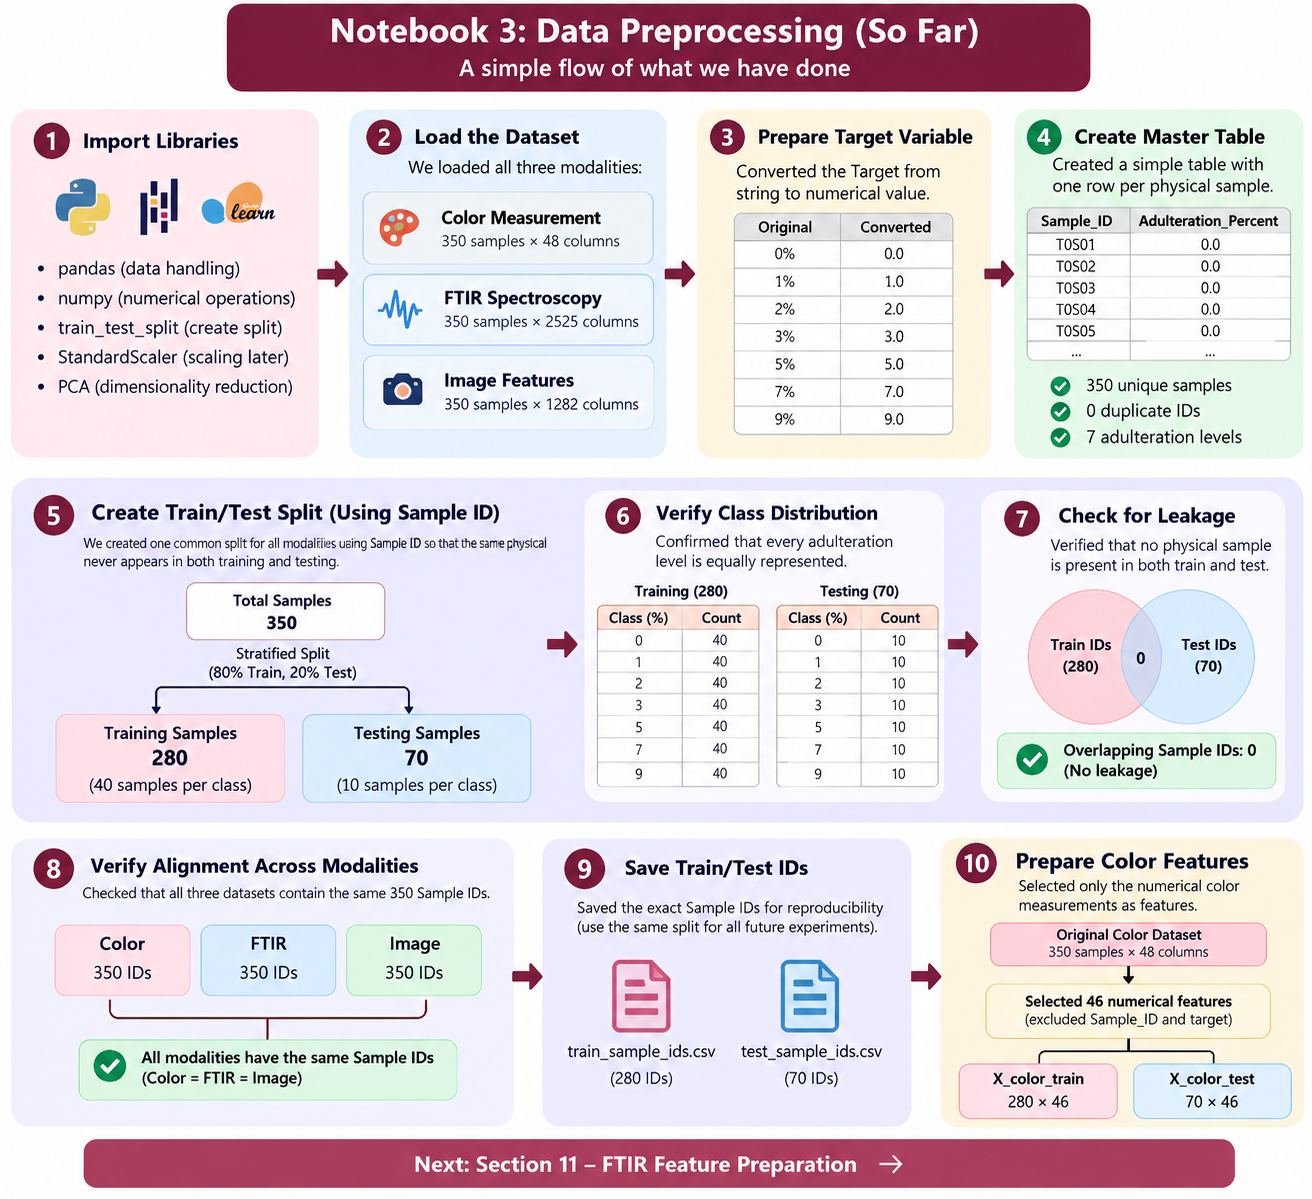
# how to attch the image 

                 FOODSure AI DATA
                       ↓
              Load 3 types of data
           ┌───────────┼───────────┐
           ↓           ↓           ↓
         Color       FTIR       Image
           │           │           │
           └───────────┼───────────┘
                       ↓
              Convert Target
            "5%" → 5.0
                       ↓
               Create Master Table
            Sample ID + Adulteration %
                       ↓
                Split the samples
                 80%     |    20%
                TRAIN    |    TEST
                 280     |     70
                       ↓
             Check class balance
               40/class | 10/class
                       ↓
              Check for leakage
                  Overlap = 0
                       ↓
             Check modality IDs
             Color = FTIR = Image
                       ↓
              Save exact split IDs
                       ↓
             Prepare COLOR data
                       ↓
             Select 46 features
                       ↓
              280 × 46  |  70 × 46
                TRAIN    |   TEST
                       ↓
              🔜 FTIR FEATURES

---------------------------------------------------

## 11. FTIR Feature Preparation

FTIR spectroscopy provides a spectral fingerprint of each turmeric sample.

The FTIR dataset contains:

- `Sample ID` — identifier of the physical sample
- `Target` — original adulteration label
- spectral measurements represented by wavenumber columns
- an additional empty column that is not a spectral feature

The spectral columns represent measurements across different wavenumbers in cm⁻¹.

Unlike the Color modality, FTIR contains a very large number of numerical features. Therefore, the spectral columns must be identified carefully before modeling.

In [664]:
# Identify columns whose names represent numerical wavenumbers

ftir_spectral_columns = []

for col in ftir.columns:
    try:
        float(col)
        ftir_spectral_columns.append(col)
    except ValueError:
        pass

print("Number of FTIR spectral features:",
      len(ftir_spectral_columns))

print("\nFirst 10 spectral columns:")
print(ftir_spectral_columns[:10])

print("\nLast 10 spectral columns:")
print(ftir_spectral_columns[-10:])

Number of FTIR spectral features: 2522

First 10 spectral columns:
['399.47297', '400.89966', '402.32635', '403.75304', '405.17973', '406.60642', '408.03311', '409.4598', '410.88649', '412.31318']

Last 10 spectral columns:
['3983.31623', '3984.74292', '3986.16961', '3987.5963', '3989.02299', '3990.44968', '3991.87637', '3993.30306', '3994.72975', '3996.15644']


🧠 What does 2522 mean?

Our FTIR dataset originally has:

350 × 2525

columns.

But not all 2525 columns are actual spectral measurements.

Conceptually:

2525 total columns
│
├── Sample ID             ❌
├── Target                ❌
├── 2522 wavenumbers      ✅
└── Unnamed: 2524         ❌

Therefore:

2522 is the actual number of FTIR input features.

This distinction is important for our research report.

-----------------------------------------------------------------------------

### 11.2 Inspect the FTIR Wavenumber Range

The spectral columns represent wavenumbers measured in inverse centimeters (cm⁻¹).

The minimum and maximum wavenumbers are calculated to verify the spectral range represented in the dataset.

In [665]:
# Convert spectral column names to numerical wavenumbers

ftir_wavenumbers = np.array(
    [float(col) for col in ftir_spectral_columns]
)

print("Minimum wavenumber:",
      ftir_wavenumbers.min(), "cm⁻¹")

print("Maximum wavenumber:",
      ftir_wavenumbers.max(), "cm⁻¹")

Minimum wavenumber: 399.47297 cm⁻¹
Maximum wavenumber: 3996.15644 cm⁻¹


### 11.3 Create the FTIR Feature Matrix

The FTIR feature matrix `X_ftir` contains only the 2522 spectral measurements.

The adulteration percentage is stored separately as `y_ftir`.

The Sample ID is retained separately so that the physical samples can be matched with the common train/test split.

In [666]:
# FTIR feature matrix

X_ftir = ftir[ftir_spectral_columns].copy()

# Use the master target so that the target representation
# remains consistent across all modalities

y_ftir = master["Adulteration_Percent"].copy()

print("X_ftir shape:", X_ftir.shape)
print("y_ftir shape:", y_ftir.shape)

X_ftir shape: (350, 2522)
y_ftir shape: (350,)


FTIR

        350 samples
        │
      ├───────────────┐
      ↓               ↓
X_ftir             y_ftir
350 × 2522          350
spectra             target

### 11.4 Verify FTIR Feature Quality

Before creating the training and test matrices, the spectral feature matrix is checked for:

- missing values
- infinite values
- numerical data types

This ensures that the spectral measurements are suitable for downstream preprocessing.

In [667]:
print("Missing FTIR values:",
      X_ftir.isna().sum().sum())

print("Infinite FTIR values:",
      np.isinf(X_ftir.to_numpy()).sum())

print("\nFTIR data types:")
print(X_ftir.dtypes.value_counts())

Missing FTIR values: 0
Infinite FTIR values: 0

FTIR data types:
float64    2522
Name: count, dtype: int64


### 11.5 Verify FTIR Sample Ordering

The FTIR data must remain aligned with the master sample table.

The Sample IDs are compared with the master table to ensure that each spectral row corresponds to the correct physical sample and target.

In [668]:
print(
    "FTIR IDs match master IDs:",
    ftir["Sample ID"].tolist()
    == master["Sample_ID"].tolist()
)

print(
    "FTIR targets match master targets:",
    y_ftir.tolist()
    == master["Adulteration_Percent"].tolist()
)

FTIR IDs match master IDs: True
FTIR targets match master targets: True


### 11.6 Split FTIR Data Using the Master Sample IDs

The previously created train/test Sample IDs are applied to the FTIR modality.

No independent random split is performed.

This guarantees that the FTIR training and test samples are identical to the physical samples used for the Color and future Image modalities.

In [669]:
train_ftir = ftir[
    ftir["Sample ID"].isin(train_ids)
].copy()

test_ftir = ftir[
    ftir["Sample ID"].isin(test_ids)
].copy()

print("Training FTIR samples:", len(train_ftir))
print("Test FTIR samples:", len(test_ftir))

Training FTIR samples: 280
Test FTIR samples: 70


### 11.7 Create Training and Test FTIR Matrices

The final FTIR feature matrices are created using the previously identified spectral columns.

The target variables remain separate.

No scaling, normalization, PCA, or feature selection is performed yet.

These transformations will be handled later using only the training data to prevent data leakage.

In [670]:
X_ftir_train = train_ftir[
    ftir_spectral_columns
].copy()

X_ftir_test = test_ftir[
    ftir_spectral_columns
].copy()

y_ftir_train = train_ftir["Sample ID"].map(
    master.set_index("Sample_ID")["Adulteration_Percent"]
)

y_ftir_test = test_ftir["Sample ID"].map(
    master.set_index("Sample_ID")["Adulteration_Percent"]
)

print("X_ftir_train:", X_ftir_train.shape)
print("X_ftir_test:", X_ftir_test.shape)

print("y_ftir_train:", y_ftir_train.shape)
print("y_ftir_test:", y_ftir_test.shape)

X_ftir_train: (280, 2522)
X_ftir_test: (70, 2522)
y_ftir_train: (280,)
y_ftir_test: (70,)


### 11.8 Verify the Final FTIR Split

The final FTIR training and test matrices are checked to confirm:

- 280 training samples
- 70 test samples
- 2522 spectral features
- no missing values
- correct target alignment

In [671]:
print("Training samples:",
      X_ftir_train.shape[0])

print("Test samples:",
      X_ftir_test.shape[0])

print("Spectral features:",
      X_ftir_train.shape[1])

print(
    "Training missing values:",
    X_ftir_train.isna().sum().sum()
)

print(
    "Test missing values:",
    X_ftir_test.isna().sum().sum()
)

print(
    "Training target classes:",
    sorted(y_ftir_train.unique())
)

print(
    "Test target classes:",
    sorted(y_ftir_test.unique())
)

Training samples: 280
Test samples: 70
Spectral features: 2522
Training missing values: 0
Test missing values: 0
Training target classes: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(5.0), np.float64(7.0), np.float64(9.0)]
Test target classes: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(5.0), np.float64(7.0), np.float64(9.0)]


              FTIR
                │
                ↓
        Identify spectral columns
                │
                ↓
          2522 features
                │
                ↓
        Master Sample ID split
             /        \
            ↓          ↓
        TRAIN          TEST
       280 × 2522    70 × 2522

-----------------------------------------------------------------------------

## 12. EfficientNet-B0 Image Feature Preparation

The Image modality is represented using pre-extracted EfficientNet-B0 features.

Instead of using raw image pixels, each turmeric image is represented by a 1280-dimensional feature vector generated by EfficientNet-B0.

The dataset contains:

- `Sample_ID` — identifier of the physical turmeric sample
- 1280 EfficientNet-B0 image features
- `Target` — adulteration level

The EfficientNet features will be prepared using the same physical-sample train/test split used for the Color and FTIR modalities.

### 12.1 Identify EfficientNet-B0 Feature Columns

The EfficientNet dataset contains identifier and target columns that must not be used as model inputs.

The remaining columns represent the 1280-dimensional image embeddings.

In [672]:
efficientnet_feature_columns = [
    col
    for col in efficientnet.columns
    if col not in ["Sample_ID", "Target"]
]

print(
    "Number of EfficientNet features:",
    len(efficientnet_feature_columns)
)

print("\nFirst 10 features:")
print(efficientnet_feature_columns[:10])

print("\nLast 10 features:")
print(efficientnet_feature_columns[-10:])

Number of EfficientNet features: 1280

First 10 features:
['Feature_1', 'Feature_2', 'Feature_3', 'Feature_4', 'Feature_5', 'Feature_6', 'Feature_7', 'Feature_8', 'Feature_9', 'Feature_10']

Last 10 features:
['Feature_1271', 'Feature_1272', 'Feature_1273', 'Feature_1274', 'Feature_1275', 'Feature_1276', 'Feature_1277', 'Feature_1278', 'Feature_1279', 'Feature_1280']


### 12.2 Create the EfficientNet Feature Matrix

The image feature matrix `X_image` contains only the 1280 EfficientNet-B0 features.

The target variable is kept separately.

The Sample ID remains available in the original dataset so that the common train/test split can be applied correctly.

In [673]:
X_image = efficientnet[
    efficientnet_feature_columns
].copy()

y_image = master[
    "Adulteration_Percent"
].copy()

print("X_image shape:", X_image.shape)
print("y_image shape:", y_image.shape)

X_image shape: (350, 1280)
y_image shape: (350,)


### 12.3 Verify EfficientNet Feature Quality

The image feature matrix is checked for:

- missing values
- infinite values
- numerical data types

This ensures that the extracted image embeddings are valid before applying further preprocessing.

In [674]:
print(
    "Missing image features:",
    X_image.isna().sum().sum()
)

print(
    "Infinite image features:",
    np.isinf(X_image.to_numpy()).sum()
)

print("\nImage feature data types:")
print(X_image.dtypes.value_counts())

Missing image features: 0
Infinite image features: 0

Image feature data types:
float64    1280
Name: count, dtype: int64


### 12.4 Verify Image Sample Ordering

The EfficientNet-B0 feature rows must correspond to the same physical samples represented in the master table.

The Sample IDs are compared with the master table to ensure that image features and targets remain correctly aligned.

In [675]:
print(
    "Image IDs match master IDs:",
    efficientnet["Sample_ID"].tolist()
    == master["Sample_ID"].tolist()
)

Image IDs match master IDs: True


### 12.5 Verify Image Target Alignment

The EfficientNet dataset contains its own target column.

We compare its target values with the master adulteration percentages to ensure that the image features are associated with the correct labels.

In [676]:
image_target = efficientnet["Target"].astype(float)

print(
    "Image targets match master targets:",
    image_target.tolist()
    == master["Adulteration_Percent"].tolist()
)

Image targets match master targets: True


### 12.6 Split Image Features Using the Master Sample IDs

The previously created train/test Sample IDs are applied to the EfficientNet-B0 dataset.

No independent random split is performed.

This ensures that the Image modality uses exactly the same physical samples as the Color and FTIR modalities.

In [677]:
train_image = efficientnet[
    efficientnet["Sample_ID"].isin(train_ids)
].copy()

test_image = efficientnet[
    efficientnet["Sample_ID"].isin(test_ids)
].copy()

print("Training image samples:", len(train_image))
print("Test image samples:", len(test_image))

Training image samples: 280
Test image samples: 70


### 12.7 Create Training and Test Image Feature Matrices

The final EfficientNet-B0 training and test matrices are created using the 1280 image feature columns.

The target variables remain separate.

No scaling or dimensionality reduction is performed yet.

In [678]:
X_image_train = train_image[
    efficientnet_feature_columns
].copy()
# Machine learning models require clean feature matrices containing only input features ($X$).
X_image_test = test_image[
    efficientnet_feature_columns
].copy()

#This guarantees that the target label assigned to each image sample strictly aligns with the master physical sample record ($0.0\%, 1.0\%, 2.0\%, 3.0\%, 5.0\%, 7.0\%, 9.0\%$).
y_image_train = train_image["Sample_ID"].map(
    master.set_index("Sample_ID")["Adulteration_Percent"]
)

y_image_test = test_image["Sample_ID"].map(
    master.set_index("Sample_ID")["Adulteration_Percent"]
)

print("X_image_train:", X_image_train.shape)
print("X_image_test:", X_image_test.shape)

print("y_image_train:", y_image_train.shape)
print("y_image_test:", y_image_test.shape)

X_image_train: (280, 1280)
X_image_test: (70, 1280)
y_image_train: (280,)
y_image_test: (70,)


### 12.8 Final Validation of the Image Split

The final EfficientNet-B0 training and test matrices are checked to confirm:

- correct number of training samples
- correct number of test samples
- 1280 image features
- no missing values
- all seven adulteration levels are represented

In [679]:
print("Training samples:",
      X_image_train.shape[0])

print("Test samples:",
      X_image_test.shape[0])

print("Image features:",
      X_image_train.shape[1])

print(
    "Training missing values:",
    X_image_train.isna().sum().sum()
)

print(
    "Test missing values:",
    X_image_test.isna().sum().sum()
)

print(
    "Training target classes:",
    sorted(y_image_train.unique())
)

print(
    "Test target classes:",
    sorted(y_image_test.unique())
)

Training samples: 280
Test samples: 70
Image features: 1280
Training missing values: 0
Test missing values: 0
Training target classes: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(5.0), np.float64(7.0), np.float64(9.0)]
Test target classes: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(5.0), np.float64(7.0), np.float64(9.0)]


                 FoodSure AI
                     │
        ┌────────────┼────────────┐
        ↓            ↓            ↓
      COLOR         FTIR        IMAGE
        │            │            │
     46 feat.     2522 feat.   1280 feat.
        │            │            │
        ↓            ↓            ↓
      280/70       280/70       280/70
     Train/Test   Train/Test   Train/Test

-----------------------------------------------------------------------------


🔹 Section 13 — Feature Scaling

Before we code, one important idea:

Why scaling:-  Our modalities have features on very different numerical scales.

For example:- 
Color features → relatively small measurement ranges
FTIR → spectral intensity values
EfficientNet → embedding values

If we use models such as SVM, Logistic Regression, PCA, features with larger numerical ranges can have more influence simply because of their scale.

So we will standardize the features using:

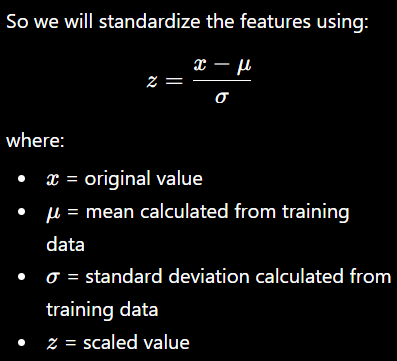

We DO NOT fit the scaler on all 350 samples.

Correct:

TRAINING DATA -> fit StandardScaler -> transform TRAIN -> transform TEST using SAME scaler

Not:

ALL DATA -> fit scaler -> split

because that would leak information from the test set.

----------------------------------------------------------------------------

# 13. Feature Scaling

Feature scaling is applied to the numerical features before using models that are sensitive to feature magnitude.

The FoodSure AI dataset contains three different feature spaces:

- Color: 46 features
- FTIR: 2522 spectral features
- Image: 1280 EfficientNet-B0 features

These features can have different numerical ranges.

Standardization transforms each feature using:

z = (x - μ) / σ

where μ and σ are calculated from the training data.

### Important Leakage Prevention Rule

The scaler is fitted only on the training data.

The same fitted scaler is then used to transform both the training and test data.

This ensures that information from the test set is not used during preprocessing.

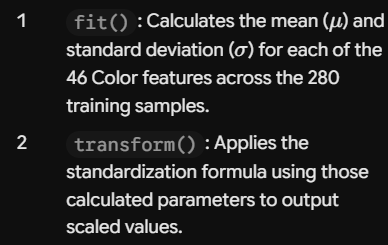

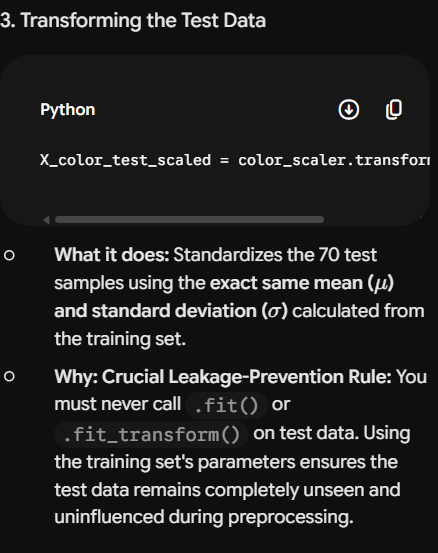

In [680]:
color_scaler = StandardScaler() #This ensures that no single color feature dominates model training simply because it has a larger numerical scale.


X_color_train_scaled = color_scaler.fit_transform(X_color_train)
X_color_test_scaled = color_scaler.transform(X_color_test)

print("Scaled Color Training Shape:", X_color_train_scaled.shape)
print("Scaled Color Test Shape:", X_color_test_scaled.shape)

Scaled Color Training Shape: (280, 46)
Scaled Color Test Shape: (70, 46)


13.4 — Verify Color Scaling

In [681]:
print("Mean of first 5 scaled Color features:")
print(X_color_train_scaled.mean(axis=0)[:5])

print("\nStandard deviation of first 5 scaled Color features:")
print(X_color_train_scaled.std(axis=0)[:5])

Mean of first 5 scaled Color features:
[ 6.39488462e-15  2.48689958e-15 -6.59789683e-16 -1.11656716e-15
  7.51145178e-15]

Standard deviation of first 5 scaled Color features:
[1. 1. 1. 1. 1.]


13.5 — Scale FTIR Features

In [682]:
ftir_scaler = StandardScaler()

X_ftir_train_scaled = ftir_scaler.fit_transform(X_ftir_train)
X_ftir_test_scaled = ftir_scaler.transform(X_ftir_test)

print("Scaled FTIR Training Shape:", X_ftir_train_scaled.shape)
print("Scaled FTIR Test Shape:", X_ftir_test_scaled.shape)

Scaled FTIR Training Shape: (280, 2522)
Scaled FTIR Test Shape: (70, 2522)


Before:

280 × 2522

        ↓ StandardScaler

After:

280 × 2522

The number of features doesn't change.

Only their scale changes.

13.6 — Verify FTIR Scaling

In [683]:
print("Mean of first 5 scaled FTIR features:")
print(X_ftir_train_scaled.mean(axis=0)[:5])

print("\nStandard deviation of first 5 scaled FTIR features:")
print(X_ftir_train_scaled.std(axis=0)[:5])

Mean of first 5 scaled FTIR features:
[ 3.78110242e-15 -2.68991179e-15 -3.50196063e-15  2.99443010e-15
 -4.06024420e-15]

Standard deviation of first 5 scaled FTIR features:
[1. 1. 1. 1. 1.]


 Why Is This Important?
 The Problem: 
 Your dataset has 2,522 FTIR features but only 280 training samples. When you have vastly more features than samples p >> n  high-dimensional problem, machine learning models can easily overfit or struggle with the "curse of dimensionality.
 
 "The Strategy: 
 First, scale the numbers so no single feature overpowers another due to unit size. After scaling is complete (in Section 14), you can evaluate whether feature selection or PCA is needed to handle the high dimension count safely.

13.7 — Scale EfficientNet Features

In [684]:
image_scaler = StandardScaler()

X_image_train_scaled = image_scaler.fit_transform(X_image_train)
X_image_test_scaled = image_scaler.transform(X_image_test)

print("Scaled Image Training Shape:", X_image_train_scaled.shape)
print("Scaled Image Test Shape:", X_image_test_scaled.shape)

Scaled Image Training Shape: (280, 1280)
Scaled Image Test Shape: (70, 1280)


13.8 — Verify Image Scaling

In [685]:
print("Mean of first 5 scaled Image features:")
print(X_image_train_scaled.mean(axis=0)[:5])

print("\nStandard deviation of first 5 scaled Image features:")
print(X_image_train_scaled.std(axis=0)[:5])

Mean of first 5 scaled Image features:
[-5.39251183e-16  2.53765263e-17  0.00000000e+00  1.01506105e-16
  2.53765263e-17]

Standard deviation of first 5 scaled Image features:
[1. 1. 1. 1. 1.]


## Interpretation

Feature scaling was successfully applied separately to the Color, FTIR, and EfficientNet-B0 feature spaces.

The scalers were fitted only on the training samples and then applied to both training and test samples. Therefore, the test data did not contribute to the calculation of scaling parameters.

Scaling did not change the number of features. It only transformed their numerical ranges so that models sensitive to feature magnitude can process the modalities more appropriately.

The original feature spaces are retained because later experiments may require the original or differently processed representations.

The FTIR modality still contains 2522 features and the image modality contains 1280 features. Therefore, dimensionality reduction or feature selection may be investigated next, especially for models that are sensitive to high-dimensional feature spaces.

-----------------------------------------------------------------------------

SECTION 14 — DIMENSIONALITY REDUCTION

# 14. Dimensionality Reduction

The FoodSure AI dataset contains a large number of features compared with the number of available training samples.

The three modalities contain:

- Color: 46 features
- FTIR: 2522 features
- EfficientNet-B0 image embeddings: 1280 features

This creates a high-dimensional feature space, particularly for FTIR spectroscopy and image embeddings.

High dimensionality can:

- increase computational cost
- increase the risk of overfitting
- make visualization difficult
- introduce redundant information
- make some machine-learning models harder to train effectively

Therefore, dimensionality reduction is investigated to determine whether the feature spaces can be represented using fewer dimensions while retaining a large proportion of the original variation.

In this project, Principal Component Analysis (PCA) is investigated as a dimensionality-reduction technique.

### Important Leakage Prevention Rule

PCA learns information from the data.

Therefore, PCA must be fitted only on the training data.

The test data is transformed using the PCA fitted on the training data.

14.3 — PCA for FTIR

## 14.3 Principal Component Analysis for FTIR

FTIR contains 2522 spectral features for only 280 training samples.

Because this is a high-dimensional feature space, PCA is investigated to understand how much of the spectral variation can be represented using a smaller number of components.

The PCA model is fitted only on the training FTIR data.

The test FTIR data is then transformed using the same fitted PCA model.

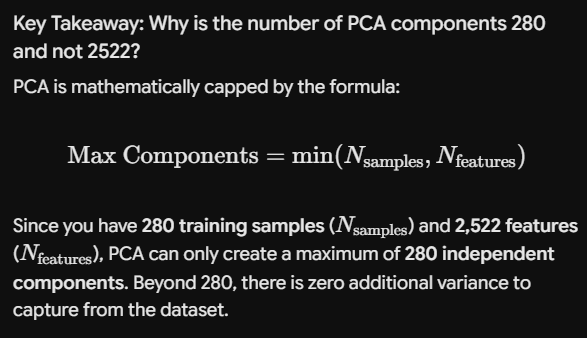

In [686]:
ftir_pca_full = PCA()

#fit(): Finds the directions of maximum variance (principal components) using only the 280 scaled FTIR training samples.
#transform(): Projects the original 2,522 spectral features onto those new component directions.

X_ftir_train_pca_full = ftir_pca_full.fit_transform(
    X_ftir_train_scaled
)
#What it does: Projects the 70 test samples onto the exact same principal components calculated from the training set.
# Why: Prevents data leakage by ensuring the test set does not influence how the principal components are calculated.
X_ftir_test_pca_full = ftir_pca_full.transform(
    X_ftir_test_scaled
)

print("Original FTIR features:", X_ftir_train_scaled.shape[1])
print("Number of PCA components:", X_ftir_train_pca_full.shape[1])

Original FTIR features: 2522
Number of PCA components: 280


14.4 — Explained Variance

In [687]:
explained_variance = ftir_pca_full.explained_variance_ratio_

print("First 10 explained variance ratios:")
print(explained_variance[:10])

First 10 explained variance ratios:
[0.46033695 0.06748629 0.02951689 0.01511134 0.00853637 0.00808761
 0.00794908 0.00771883 0.0076483  0.00756637]


In [688]:
cumulative_variance = np.cumsum(explained_variance)

print("Cumulative variance after first 10 components:")
print(cumulative_variance[:10])

Cumulative variance after first 10 components:
[0.46033695 0.52782323 0.55734012 0.57245146 0.58098783 0.58907544
 0.59702452 0.60474334 0.61239165 0.61995801]


🚨 The important observation

PC1 alone captures ~46% of the total FTIR variance.

That's quite substantial.

Then PC1 + PC2 already capture:

$$ 46.03 + 6.75 = 52.78\% $$

And the first 10 components capture approximately 61.99\%.

So although FTIR has 2522 original features, a relatively small number of principal directions already captures a large amount of the variation.

But remember:

Variance ≠ predictive performance.

We cannot say PC1 is "46% adulteration detection" or that these components are automatically the best features for classification. PCA is unsupervised—it is only looking at variance in the FTIR data.

## 14.5 Cumulative Explained Variance

The cumulative explained variance curve shows how much of the total variation in the FTIR training data is retained as additional principal components are included.

This visualization helps identify how quickly the high-dimensional FTIR feature space can be represented using fewer dimensions.

The curve is used to identify candidate dimensionalities for later machine-learning experiments.

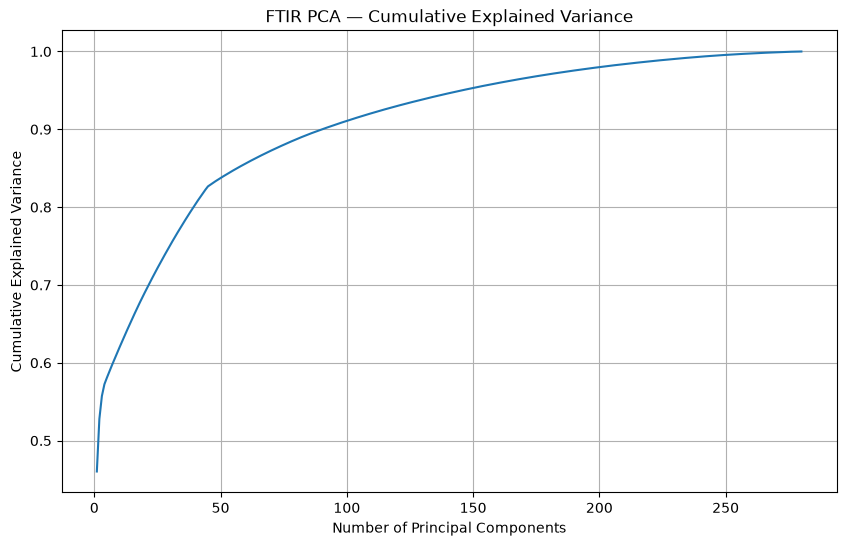

In [689]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("FTIR PCA — Cumulative Explained Variance")
plt.grid(True)

plt.show()

📊 What your graph tells us

The curve starts at about 46% because PC1 alone explains ~46.03% of the FTIR variance.

Then it rises quickly:

First 10 PCs → ~62.0%
Around 50 PCs → ~83%
Around 100 PCs → ~91%
Around 150 PCs → ~95%
Around 200 PCs → ~98%
Around 250 PCs → ~99%+

So the FTIR feature space has a lot of redundancy: we don't necessarily need all 2522 original spectral dimensions to represent most of the variance.

But ⚠️ we are NOT saying that 100 or 150 PCs will give the best model. PCA is unsupervised.

## 14.6 PCA Variance Threshold Analysis

To identify candidate dimensionalities for later experiments, we calculate the number of principal components required to retain:

- 90% of the variance
- 95% of the variance
- 99% of the variance

These values will be used as candidate PCA configurations during later modeling experiments.

In [690]:
variance_thresholds = [0.90, 0.95, 0.99]

for threshold in variance_thresholds:
    n_components = np.argmax(
        cumulative_variance >= threshold
    ) + 1

    print(
        f"{threshold*100:.0f}% variance requires "
        f"{n_components} components"
    )

90% variance requires 91 components
95% variance requires 146 components
99% variance requires 229 components


FTIR
2522 features
      ↓
     PCA
      ↓
 
   90% variance    → candidate A

   95% variance    → candidate B
   
   99% variance   → candidate C
 
 ## Interpretation

The FTIR dataset originally contains 2522 spectral features.

PCA shows that:

- 91 components retain 90% of the variance.
- 146 components retain 95% of the variance.
- 229 components retain 99% of the variance.

Therefore, PCA can substantially reduce the dimensionality of the FTIR feature space while retaining a large proportion of its variance.

For example, reducing 2522 features to 91 components decreases the feature dimensionality considerably while retaining 90% of the observed variance.

These values are treated as candidate PCA configurations for later machine-learning experiments. The final choice will not be made using explained variance alone; downstream model performance and generalization will also be considered.

## 14.7 Principal Component Analysis for EfficientNet-B0 Features

The EfficientNet-B0 image representation contains 1280 learned features for each sample.

These features are extracted image representations rather than directly interpretable physical measurements.

PCA is applied to investigate whether these 1280 dimensions can be represented using fewer components while retaining a large proportion of the variance.

As with FTIR, PCA is fitted only on the training image features and then applied to the test features.

In [691]:
image_pca_full = PCA()

X_image_train_pca_full = image_pca_full.fit_transform(
    X_image_train_scaled
)

X_image_test_pca_full = image_pca_full.transform(
    X_image_test_scaled
)

print("Original Image features:", X_image_train_scaled.shape[1])
print("Number of PCA components:", X_image_train_pca_full.shape[1])

Original Image features: 1280
Number of PCA components: 280


In [692]:
image_explained_variance = (
    image_pca_full.explained_variance_ratio_
)

image_cumulative_variance = np.cumsum(
    image_explained_variance
)

print("First 10 Image PCA explained variance ratios:")
print(image_explained_variance[:10])

print("\nCumulative variance after first 10 components:")
print(image_cumulative_variance[:10])

First 10 Image PCA explained variance ratios:
[0.2440414  0.13510078 0.07304053 0.06330307 0.0456223  0.03698397
 0.03067171 0.02830574 0.02451844 0.01905179]

Cumulative variance after first 10 components:
[0.2440414  0.37914218 0.45218272 0.51548579 0.56110809 0.59809206
 0.62876377 0.65706951 0.68158795 0.70063974]


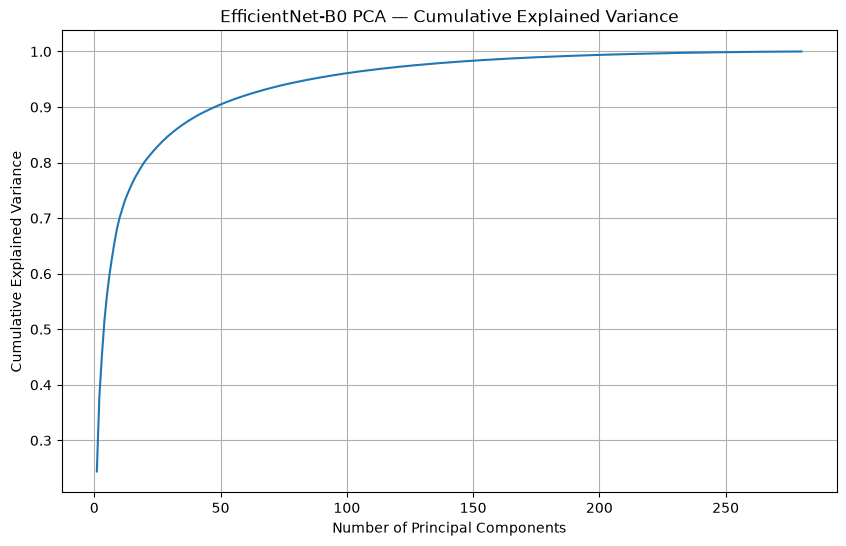

In [693]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(image_cumulative_variance) + 1),
    image_cumulative_variance
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("EfficientNet-B0 PCA — Cumulative Explained Variance")
plt.grid(True)

plt.show()

Yesss 🔥 this EfficientNet PCA curve looks good and shows a very clear pattern.

What we can already see

The curve rises very quickly at the beginning:

The first few components capture a large amount of variance.
Around 50 components, the curve is already around 90%.
After that, the curve gradually flattens.
By roughly 150–200 components, most of the variance has been captured.

But again, we'll use the exact calculated thresholds, not estimates from the graph.

## 14.10 PCA Variance Threshold Analysis for Image Features

The cumulative explained variance curve indicates that the EfficientNet-B0 feature space can potentially be represented using fewer dimensions.

To identify candidate dimensionalities for later experiments, the number of principal components required to retain 90%, 95%, and 99% of the variance is calculated.

These values will be treated as candidate configurations for downstream machine-learning experiments.

In [694]:
image_variance_thresholds = [0.90, 0.95, 0.99]

for threshold in image_variance_thresholds:
    n_components = np.argmax(
        image_cumulative_variance >= threshold
    ) + 1

    print(
        f"{threshold*100:.0f}% variance requires "
        f"{n_components} components"
    )

90% variance requires 48 components
95% variance requires 86 components
99% variance requires 177 components


## Interpretation

The EfficientNet-B0 representation originally contains 1280 learned image features.

PCA shows that:

- 48 components retain 90% of the variance.
- 86 components retain 95% of the variance.
- 177 components retain 99% of the variance.

This indicates that the image feature space contains substantial redundancy, since a much smaller number of principal components can represent a large proportion of the observed variance.

However, variance retention does not directly indicate adulteration-prediction performance. These PCA configurations will therefore be treated as candidate representations for later supervised-learning experiments.

The EfficientNet-B0 features represent learned image information and should not be interpreted as individual human-readable physical measurements.

## 14.11 Principal Component Analysis for Color Features

The Color modality contains 46 numerical features, consisting of Hunter Lab measurements and wavelength-based measurements.

Compared with FTIR and EfficientNet-B0, the Color feature space is relatively small.

PCA is therefore investigated primarily to understand the amount of redundancy among the color features. Dimensionality reduction will only be considered for later modeling if it provides a useful representation without reducing predictive performance.

As with the other modalities, PCA is fitted only on the training data.

In [695]:
color_pca_full = PCA()

X_color_train_pca_full = color_pca_full.fit_transform(
    X_color_train_scaled
)

X_color_test_pca_full = color_pca_full.transform(
    X_color_test_scaled
)

print("Original Color features:", X_color_train_scaled.shape[1])
print("Number of PCA components:", X_color_train_pca_full.shape[1])

Original Color features: 46
Number of PCA components: 46


In [696]:
color_explained_variance = (
    color_pca_full.explained_variance_ratio_
)

color_cumulative_variance = np.cumsum(
    color_explained_variance
)

print("First 10 Color PCA explained variance ratios:")
print(color_explained_variance[:10])

print("\nCumulative variance after first 10 components:")
print(color_cumulative_variance[:10])

First 10 Color PCA explained variance ratios:
[9.14636168e-01 7.02214453e-02 9.68037587e-03 1.79325271e-03
 1.51056871e-03 1.08882258e-03 4.24505181e-04 2.58581237e-04
 1.05450318e-04 4.81857017e-05]

Cumulative variance after first 10 components:
[0.91463617 0.98485761 0.99453799 0.99633124 0.99784181 0.99893063
 0.99935514 0.99961372 0.99971917 0.99976736]


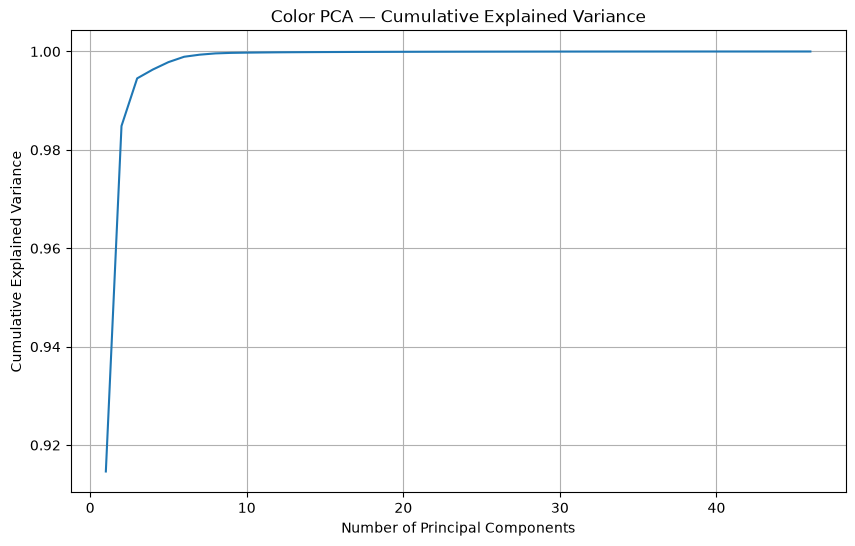

In [697]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(color_cumulative_variance) + 1),
    color_cumulative_variance
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Color PCA — Cumulative Explained Variance")
plt.grid(True)

plt.show()

In [698]:
color_variance_thresholds = [0.90, 0.95, 0.99]

for threshold in color_variance_thresholds:
    n_components = np.argmax(
        color_cumulative_variance >= threshold
    ) + 1

    print(
        f"{threshold*100:.0f}% variance requires "
        f"{n_components} components"
    )

90% variance requires 1 components
95% variance requires 2 components
99% variance requires 3 components


## Interpretation

The Color modality contains 46 numerical features, but the PCA analysis shows that most of the observed variance can be represented using only a small number of principal components.

The results show that:

- 1 component retains 90% of the variance.
- 2 components retain 95% of the variance.
- 3 components retain 99% of the variance.

This indicates substantial redundancy among the Color features. The result is consistent with the strong relationships observed between several wavelength measurements during exploratory data analysis.

However, retaining 99% of the variance does not guarantee that three components will provide the best adulteration-prediction performance. Therefore, PCA-reduced Color representations will be treated as candidate representations for later supervised-learning experiments.

Because the original Color feature space contains only 46 features, both the original and PCA-reduced representations can be retained for comparison.

## 14.12 Dimensionality Reduction Summary

PCA was investigated independently for the Color, FTIR, and EfficientNet-B0 image feature spaces.

The number of components required to retain different levels of variance was recorded for each modality.

| Modality | Original Features | 90% Variance | 95% Variance | 99% Variance |
|----------|------------------:|--------------:|--------------:|--------------:|
| Color | 46 | 1 | 2 | 3 |
| FTIR | 2522 | 91 | 146 | 229 |
| EfficientNet-B0 | 1280 | 48 | 86 | 177 |

The results indicate substantial dimensional redundancy across all three modalities.

The Color features show the strongest dimensional reduction, while FTIR requires a larger number of components to retain the same proportion of variance.

These PCA configurations are candidate representations for subsequent supervised-learning experiments. PCA will not automatically replace the original feature spaces because dimensionality reduction should ultimately be evaluated based on predictive performance and generalization.

-----------------------------------------------------------------------------

# 15. Candidate Reduced Feature Representations

The PCA analysis identified several candidate dimensionalities for each modality.

The selected candidates are based on variance-retention thresholds:

- Color: 3 components for approximately 99% variance
- FTIR: 91 components for approximately 90% variance
- Image: 48 components for approximately 90% variance

These reduced representations will be used as candidate inputs for later machine-learning experiments.

The original feature spaces are retained separately because PCA-based dimensionality reduction may not always improve predictive performance.

All PCA transformations were fitted using training data only.

15.2 — Color: 3 Components

In [699]:
color_pca_3 = PCA(n_components=3)

X_color_train_pca = color_pca_3.fit_transform(
    X_color_train_scaled
)

X_color_test_pca = color_pca_3.transform(
    X_color_test_scaled
)

print("PCA Color Training Shape:", X_color_train_pca.shape)
print("PCA Color Test Shape:", X_color_test_pca.shape)

PCA Color Training Shape: (280, 3)
PCA Color Test Shape: (70, 3)


In [700]:
print(
    "Color PCA explained variance:",
    color_pca_3.explained_variance_ratio_.sum()
)

Color PCA explained variance: 0.9945379889229089


15.3 — FTIR: 90% Candidate

In [701]:
ftir_pca_90 = PCA(n_components=91)

X_ftir_train_pca = ftir_pca_90.fit_transform(
    X_ftir_train_scaled
)

X_ftir_test_pca = ftir_pca_90.transform(
    X_ftir_test_scaled
)

print("PCA FTIR Training Shape:", X_ftir_train_pca.shape)
print("PCA FTIR Test Shape:", X_ftir_test_pca.shape)

PCA FTIR Training Shape: (280, 91)
PCA FTIR Test Shape: (70, 91)


In [702]:
print(
    "FTIR PCA explained variance:",
    ftir_pca_90.explained_variance_ratio_.sum()
)

FTIR PCA explained variance: 0.8999621550388485


15.4 — Image: 90% Candidate

In [703]:
image_pca_90 = PCA(n_components=48)

X_image_train_pca = image_pca_90.fit_transform(
    X_image_train_scaled
)

X_image_test_pca = image_pca_90.transform(
    X_image_test_scaled
)

print("PCA Image Training Shape:", X_image_train_pca.shape)
print("PCA Image Test Shape:", X_image_test_pca.shape)

PCA Image Training Shape: (280, 48)
PCA Image Test Shape: (70, 48)


In [704]:
print(
    "Image PCA explained variance:",
    image_pca_90.explained_variance_ratio_.sum()
)

Image PCA explained variance: 0.9004522281524532


In [705]:
print("Candidate PCA Representations")
print("-" * 45)

print("Color:")
print("  Original:", X_color_train.shape)
print("  PCA:", X_color_train_pca.shape)

print("\nFTIR:")
print("  Original:", X_ftir_train.shape)
print("  PCA:", X_ftir_train_pca.shape)

print("\nImage:")
print("  Original:", X_image_train.shape)
print("  PCA:", X_image_train_pca.shape)

Candidate PCA Representations
---------------------------------------------
Color:
  Original: (280, 46)
  PCA: (280, 3)

FTIR:
  Original: (280, 2522)
  PCA: (280, 91)

Image:
  Original: (280, 1280)
  PCA: (280, 48)


## 15.6 Final Train/Test Validation

Before saving the preprocessed representations, the training and test datasets are validated once again.

The validation checks:

- training and test dimensions
- target dimensions
- class distribution
- missing values
- infinite values
- train/test sample separation

This ensures that the data passed to the modeling notebooks is consistent and leakage-safe.

In [706]:
print("===== FINAL SHAPE VALIDATION =====")

print("\nColor:")
print("Train:", X_color_train_pca.shape)
print("Test :", X_color_test_pca.shape)

print("\nFTIR:")
print("Train:", X_ftir_train_pca.shape)
print("Test :", X_ftir_test_pca.shape)

print("\nImage:")
print("Train:", X_image_train_pca.shape)
print("Test :", X_image_test_pca.shape)

print("\nTargets:")
print("Train:", y_color_train.shape)
print("Test :", y_color_test.shape)

===== FINAL SHAPE VALIDATION =====

Color:
Train: (280, 3)
Test : (70, 3)

FTIR:
Train: (280, 91)
Test : (70, 91)

Image:
Train: (280, 48)
Test : (70, 48)

Targets:
Train: (280,)
Test : (70,)


15.6.2 — Check Missing & Infinite Values

In [707]:
print("===== MISSING VALUE CHECK =====")

print("Color train:", np.isnan(X_color_train_pca).sum())
print("Color test :", np.isnan(X_color_test_pca).sum())

print("FTIR train :", np.isnan(X_ftir_train_pca).sum())
print("FTIR test  :", np.isnan(X_ftir_test_pca).sum())

print("Image train:", np.isnan(X_image_train_pca).sum())
print("Image test :", np.isnan(X_image_test_pca).sum())

print("\n===== INFINITE VALUE CHECK =====")

print("Color train:", np.isinf(X_color_train_pca).sum())
print("Color test :", np.isinf(X_color_test_pca).sum())

print("FTIR train :", np.isinf(X_ftir_train_pca).sum())
print("FTIR test  :", np.isinf(X_ftir_test_pca).sum())

print("Image train:", np.isinf(X_image_train_pca).sum())
print("Image test :", np.isinf(X_image_test_pca).sum())

===== MISSING VALUE CHECK =====
Color train: 0
Color test : 0
FTIR train : 0
FTIR test  : 0
Image train: 0
Image test : 0

===== INFINITE VALUE CHECK =====
Color train: 0
Color test : 0
FTIR train : 0
FTIR test  : 0
Image train: 0
Image test : 0


15.6.3 — Check Class Distribution

In [708]:
print("===== TRAINING CLASS DISTRIBUTION =====")
print(y_color_train.value_counts().sort_index())

print("\n===== TEST CLASS DISTRIBUTION =====")
print(y_color_test.value_counts().sort_index())

===== TRAINING CLASS DISTRIBUTION =====
Adulteration_Percent
0.0    40
1.0    40
2.0    40
3.0    40
5.0    40
7.0    40
9.0    40
Name: count, dtype: int64

===== TEST CLASS DISTRIBUTION =====
Adulteration_Percent
0.0    10
1.0    10
2.0    10
3.0    10
5.0    10
7.0    10
9.0    10
Name: count, dtype: int64


15.6.4 — Final Leakage Check

In [709]:
train_id_set = set(train_ids)
test_id_set = set(test_ids)

overlap = train_id_set.intersection(test_id_set)

print("Training samples:", len(train_id_set))
print("Testing samples :", len(test_id_set))
print("Overlapping IDs :", len(overlap))

Training samples: 280
Testing samples : 70
Overlapping IDs : 0


# 16. Save Preprocessed Data

The validated preprocessing outputs are saved so that downstream notebooks can directly load the prepared datasets.

Saving the preprocessing outputs provides:

- reproducibility
- consistent train/test splits
- faster model development
- prevention of accidental re-splitting
- prevention of inconsistent preprocessing between experiments

Both the candidate PCA representations and the corresponding sample IDs are saved.

In [710]:
import os

preprocessed_dir = "../preprocessed"

os.makedirs(preprocessed_dir, exist_ok=True)

print("Preprocessed data directory:", preprocessed_dir)

Preprocessed data directory: ../preprocessed


In [711]:
# save the targets 
y_color_train.to_csv(
    os.path.join(preprocessed_dir, "y_train.csv"),
    index=False
)

y_color_test.to_csv(
    os.path.join(preprocessed_dir, "y_test.csv"),
    index=False
)

print("Target arrays saved successfully.")

Target arrays saved successfully.


In [712]:
# save color pcs traing and test data 
pd.DataFrame(X_color_train_pca).to_csv(
    os.path.join(preprocessed_dir, "X_color_train_pca.csv"),
    index=False
)

pd.DataFrame(X_color_test_pca).to_csv(
    os.path.join(preprocessed_dir, "X_color_test_pca.csv"),
    index=False
)

In [713]:
 # save ftir pcs traing and test data 

pd.DataFrame(X_ftir_train_pca).to_csv(
    os.path.join(preprocessed_dir, "X_ftir_train_pca.csv"),
    index=False
)

pd.DataFrame(X_ftir_test_pca).to_csv(
    os.path.join(preprocessed_dir, "X_ftir_test_pca.csv"),
    index=False
)

In [714]:
# save image pcs traing and test data 
pd.DataFrame(X_image_train_pca).to_csv(
    os.path.join(preprocessed_dir, "X_image_train_pca.csv"),
    index=False
)

pd.DataFrame(X_image_test_pca).to_csv(
    os.path.join(preprocessed_dir, "X_image_test_pca.csv"),
    index=False
)

In [715]:
pd.DataFrame(X_color_train_scaled).to_csv(
    os.path.join(preprocessed_dir, "X_color_train_scaled.csv"),
    index=False
)

pd.DataFrame(X_color_test_scaled).to_csv(
    os.path.join(preprocessed_dir, "X_color_test_scaled.csv"),
    index=False
)

pd.DataFrame(X_ftir_train_scaled).to_csv(
    os.path.join(preprocessed_dir, "X_ftir_train_scaled.csv"),
    index=False
)

pd.DataFrame(X_ftir_test_scaled).to_csv(
    os.path.join(preprocessed_dir, "X_ftir_test_scaled.csv"),
    index=False
)

pd.DataFrame(X_image_train_scaled).to_csv(
    os.path.join(preprocessed_dir, "X_image_train_scaled.csv"),
    index=False
)

pd.DataFrame(X_image_test_scaled).to_csv(
    os.path.join(preprocessed_dir, "X_image_test_scaled.csv"),
    index=False
)

print("Scaled feature matrices saved successfully.")

Scaled feature matrices saved successfully.


In [716]:
import joblib

In [717]:
joblib.dump(
    color_scaler,
    os.path.join(preprocessed_dir, "color_scaler.pkl")
)

joblib.dump(
    ftir_scaler,
    os.path.join(preprocessed_dir, "ftir_scaler.pkl")
)

joblib.dump(
    image_scaler,
    os.path.join(preprocessed_dir, "image_scaler.pkl")
)

joblib.dump(
    color_pca_3,
    os.path.join(preprocessed_dir, "color_pca_3.pkl")
)

joblib.dump(
    ftir_pca_90,
    os.path.join(preprocessed_dir, "ftir_pca_90.pkl")
)

joblib.dump(
    image_pca_90,
    os.path.join(preprocessed_dir, "image_pca_90.pkl")
)

print("Scalers and PCA objects saved successfully.")

Scalers and PCA objects saved successfully.


In [718]:
print("Files saved in preprocessed directory:\n")

for file in sorted(os.listdir(preprocessed_dir)):
    print(file)

Files saved in preprocessed directory:

X_color_test_pca.csv
X_color_test_scaled.csv
X_color_train_pca.csv
X_color_train_scaled.csv
X_ftir_test_pca.csv
X_ftir_test_scaled.csv
X_ftir_train_pca.csv
X_ftir_train_scaled.csv
X_image_test_pca.csv
X_image_test_scaled.csv
X_image_train_pca.csv
X_image_train_scaled.csv
color_pca_3.pkl
color_scaler.pkl
ftir_pca_90.pkl
ftir_scaler.pkl
image_pca_90.pkl
image_scaler.pkl
y_test.csv
y_train.csv


# Conclusion

The FoodSure AI preprocessing pipeline has been completed for the three available modalities: Color, FTIR spectroscopy, and EfficientNet-B0 image features.

The dataset was first organized using a common Sample ID and divided into a leakage-safe training and test set containing 280 and 70 physical samples respectively.

The training and test sets maintain the original balanced class distribution, with 40 training samples and 10 test samples for each adulteration level.

Feature scaling was performed separately for each modality using parameters learned only from the training data.

PCA was then investigated to understand the dimensionality and redundancy of the feature spaces.

The analysis showed:

- Color: 46 original features → 3 components for approximately 99% variance
- FTIR: 2522 original features → 91 components for approximately 90% variance
- EfficientNet-B0: 1280 original features → 48 components for approximately 90% variance

These reduced representations provide candidate feature spaces for later machine-learning experiments.

The original scaled feature representations have also been retained because PCA dimensionality reduction should not be assumed to improve predictive performance without experimental validation.

All preprocessing outputs, sample IDs, scalers, and PCA objects have been saved for reproducible downstream modeling.

## Next Step

The next notebook will use these prepared representations to establish baseline machine-learning models for turmeric adulteration detection and estimation.